In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('final_data.csv')
df.drop(columns='Unnamed: 0', inplace=True)
df.head()

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...


## clean missing data

ada sedikit update stlh dicek web pergikuliner, beberapa restoran dibawah ini sudah tutup

In [3]:
idx_hapus = df[df['Restaurant Name'] == 'Sunday Bowl Cereal Club'].index
idx_hapus = idx_hapus.union(
    df[(df['Restaurant Name'] == 'Gelato Secrets') & (df['Location'] == 'Senopati')].index
)
df = df.drop(idx_hapus).reset_index(drop=True)

In [4]:
pricena = df[df['Price'].isna()]
price = pricena[['Restaurant Name', 'Location']].drop_duplicates()
price

,Restaurant Name,Location
1659,Lee Palace,Kelapa Gading
5932,Jowa,Kelapa Gading
6793,Talaga Sampireun,Kelapa Gading
9460,Indoguna Gourmet,Blok M
9495,LOF Coffee & Tea,Jagakarsa
9542,Golden Sense International Restaurant,Senayan
10386,Harum Manis,Pancoran
12000,Ajwad Restaurant,Pondok Indah
12895,Saemaeul Korean BBQ,Pantai Indah Kapuk
17902,Gyu Kaku,Cempaka Putih


In [5]:
df = df.dropna(subset=['Price']).reset_index(drop=True)

### check isna data

beberapa kolom hilang datanya saat proses scraping karena ... Untuk mengisi nya menggunakan fillna dan data kosong diambil dari website pergi kuliner langsung

In [6]:
df.isna().sum()

Restaurant Name        0
Cuisine Type           0
Restaurant Rating    985
Location               0
Price                  0
Username               0
User Rating            0
User Review            0
dtype: int64

In [7]:
df[df['Restaurant Rating'].isna()]

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
2023,Amuz,Perancis,NaN,SCBD,Di atas Rp. 200.000 /orang,CiciOgahDiet,4.4,Bday dinner\nPertama x cobain dsini\nBerasa ba...
2024,Amuz,Perancis,NaN,SCBD,Di atas Rp. 200.000 /orang,michelle_siaril,4.4,Amuz\nWell established french restaurant in Ja...
2025,Amuz,Perancis,NaN,SCBD,Di atas Rp. 200.000 /orang,kevin_suryadi,5.0,One of the best fine dining experience i ever ...
2026,Amuz,Perancis,NaN,SCBD,Di atas Rp. 200.000 /orang,siennaaa19,4.8,Amazing and Exquisite Dining Experience\nAMUZ ...
2027,Amuz,Perancis,NaN,SCBD,Di atas Rp. 200.000 /orang,Darsehsri,4.2,"French Fine Dining\nDuck Liver Foie Gras, ini ..."
...,...,...,...,...,...,...,...,...
22968,Kabobs,Arab/Timur Tengah,NaN,Menteng,Di bawah Rp. 50.000 /orang,antihungryclub,5.0,Segar\n[Klepon Segar Nikmat di Dineinc 🍾]\n\n\...
22969,Kabobs,Arab/Timur Tengah,NaN,Menteng,Di bawah Rp. 50.000 /orang,melissa_fransisca,4.6,Es Serut Unik\nNyobain es serutnya neng goela ...
22970,Kabobs,Arab/Timur Tengah,NaN,Menteng,Di bawah Rp. 50.000 /orang,m.adhiwana,3.6,"Neng Goela\nKe Dineinc, cobain es klepon bahag..."
22971,Kabobs,Arab/Timur Tengah,NaN,Menteng,Di bawah Rp. 50.000 /orang,FoodieDiary,4.2,Es Serut terenak\nSuka banget sama es serut Ne...


In [8]:
# fill isna data
fill_values = {
    'Amuz': 4.45,
    'Coco Bakehouse': 4.32,
    'Kalia': 4.28,
    'TERU' : 4.28,
    'Plataran' : 4.34,
    'The Social Pot' : 4.30,
    'Kopi Selamat Pagi' : 4.34, 
    'Okinawa Sushi' : 4.36,
    'Sushi Hiro' : 4.32,
    'Social Garden' : 4.27,
    'Fish & Chips ThreeHouse' : 4.32,
    'Olive Tree House of Croissants' : 4.27,
    'Lustre' : 4.4,
    'Blue Terrace - Hotel Ayana Midplaza Jakarta' : 4.43,
    'Bruno Cafe In The Park' : 4.42,
    'Paris Sorbet' : 4.25,
    'Blau Eatery & Coffee' : 4.35,
    'Le Gran Cafe - Hotel Gran Mahakam' : 4.24,
    'Skye' : 4.27,
    'Padang Merdeka' : 4.24,
    '2Tang 2Go' : 4.43,
    'The Writers Bar - Raffles Jakarta Hotel' : 4.37,
    'Mardin Fine Baklava Cafe' : 4.42,
    'Remboelan' : 4.28,
    'Kohai Sushi Bar' : 4.38,
    'Haiseafood' : 4.47,
    'Sugar & Spice - Hotel InterContinental Jakarta Pondok Indah' : 4.54,
    'Enmaru' : 4.21,
    'Monsieur Spoon' : 4.22,
    'Rumah Kopi Papowi' : 4.45,
    'Jia Dining - Hotel Shangri-La Jakarta' : 4.28,
    'Marutama Ra-men' : 4.21,
    'Mardin Baklava Patisserie' : 4.36,
    '/Grams Crafted Grill & Smoke' : 4.33,
    'Shabu Siy' : 4.40,
    'Coffee & Thyme' : 4.32,
    'Cafe Batavia' : 3.99,
    'Kabobs' : 3.5,
    'Dough Lab' : 4.29
}

for resto, rating in fill_values.items():
    df.loc[(df['Restaurant Name'] == resto) & (df['Restaurant Rating'].isna()), 'Restaurant Rating'] = rating

In [9]:
# final check isna data
df.isna().sum()

Restaurant Name      0
Cuisine Type         0
Restaurant Rating    0
Location             0
Price                0
Username             0
User Rating          0
User Review          0
dtype: int64

In [10]:
df.to_csv('final_processed_data.csv')

## eda

In [11]:
df = pd.read_csv('final_processed_data.csv')
df.drop(columns='Unnamed: 0', inplace=True)
df.head()

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...


In [12]:
df.columns

Index(['Restaurant Name', 'Cuisine Type', 'Restaurant Rating', 'Location',
       'Price', 'Username', 'User Rating', 'User Review'],
      dtype='object')

In [13]:
df.shape

(28151, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28151 entries, 0 to 28150
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Restaurant Name    28151 non-null  object 
 1   Cuisine Type       28151 non-null  object 
 2   Restaurant Rating  28151 non-null  float64
 3   Location           28151 non-null  object 
 4   Price              28151 non-null  object 
 5   Username           28151 non-null  object 
 6   User Rating        28151 non-null  float64
 7   User Review        28151 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.7+ MB


In [15]:
df.describe()

,Restaurant Rating,User Rating
count,28151.000000,28151.000000
mean,4.175262,4.116635
std,0.159253,0.486955
min,3.500000,1.000000
25%,4.060000,3.800000
50%,4.130000,4.000000
75%,4.260000,4.400000
max,5.000000,5.000000


In [16]:
df.head()

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...


In [17]:
df['Cuisine Type'].value_counts()
# 76 cuisine category

Cuisine Type
Kafe                         9274
Jepang                       6179
Indonesia                    2178
Barat                        1961
China                        1907
                             ... 
Yoghurt                         8
Barat, Italia, Indonesia        7
Indonesia, Barat                7
Toko Roti dan Kue,Dessert       5
Bakpao                          4
Name: count, Length: 76, dtype: int64

In [18]:
df['Username'].value_counts()
# 3382 users

Username
placetogoandeat            627
UrsAndNic                  562
FannieHuang                389
andrikanadia               357
aileen_natalia_salim       340
                          ... 
tiffany_amelia               1
salsa.ramno                  1
nadirasyftr                  1
raja.makan                   1
tonosumarsono_gmail_com      1
Name: count, Length: 3382, dtype: int64

In [19]:
df['Location'].value_counts()
# yang tersebar di 90 lokasi di jakarta
# lokasi - jumlah review

Location
Thamrin               2953
Kelapa Gading         2792
Slipi                 1543
Pantai Indah Kapuk    1529
Senopati              1523
                      ... 
Pondok Bambu             6
Jembatan Lima            4
Pasar Rebo               4
Daan Mogot               3
Cililitan                1
Name: count, Length: 90, dtype: int64

In [20]:
df['Restaurant Name'].value_counts()
# 1046 restaurants

Restaurant Name
Sushi Tei                              494
Sushi Hiro                             404
Starbucks                              288
Coco Ichibanya                         264
Marugame Udon                          207
                                      ... 
Point Coffee                             1
Chatelier                                1
KLTR Coffee Roasters                     1
Bouclette Sourdough Bakery & Dining      1
Colette Lola                             1
Name: count, Length: 1046, dtype: int64

In [21]:
# highest rated restaurant/cafes
avg = df[['Restaurant Name', 'User Rating']].groupby(['Restaurant Name']).mean()
avg.sort_values('User Rating', ascending=False)

,User Rating
Restaurant Name,
Mokka Coffee Cabana,5.000000
Colette Lola,5.000000
Warung Kina,4.960000
May Star Signature - Sari Pacific Hotel,4.920000
KopTul,4.866667
...,...
Wu Fuk Noodle House,3.657143
Sate Khas Senayan,3.636364
Bouclette Sourdough Bakery & Dining,3.600000


In [23]:
# restaurant that should not be recommended to people : < 3 rating
not_recommended = df[df['Restaurant Rating'] < 3].value_counts()
print(f'There are {len(not_recommended)} restaurants that should not be recommended')

There are 0 restaurants that should not be recommended


## vis

In [24]:
import matplotlib.pyplot as plt

user rating & restaurant rating distribution

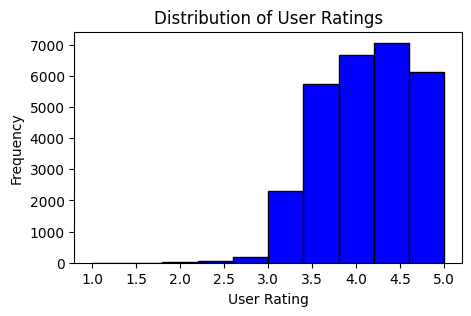

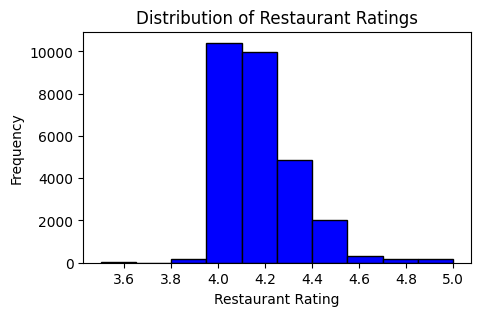

In [25]:
# user rating dist
plt.figure(figsize=(5, 3))
plt.hist(df['User Rating'], bins=10, edgecolor='black', color='blue')
plt.title('Distribution of User Ratings')
plt.xlabel('User Rating')
plt.ylabel('Frequency')
plt.show()

# restaurant rating dist
plt.figure(figsize=(5, 3))
plt.hist(df['Restaurant Rating'], bins=10, edgecolor='black', color='blue')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Restaurant Rating')
plt.ylabel('Frequency')
plt.show()

based on the visualized data, it can be seen that user rating has positive skewness\
Most ratings are on the higher end, indicating that people tend to rate positively. This is common in many review systems because people who are satisfied are more likely to leave a review.

Top 10 Cuisine Type with Most Reviews

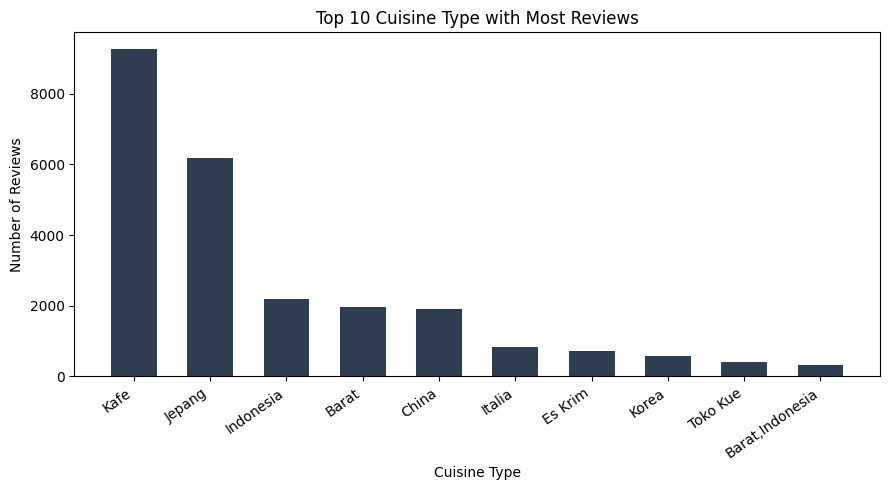

In [28]:
cuisine_counts = df['Cuisine Type'].value_counts()
top_10_cuisines = cuisine_counts.head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_10_cuisines.index, top_10_cuisines.values, color='#2C3E50', width=0.6)

plt.xlabel("Cuisine Type")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Cuisine Type with Most Reviews")

plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Top 10 Locations with Most Reviews

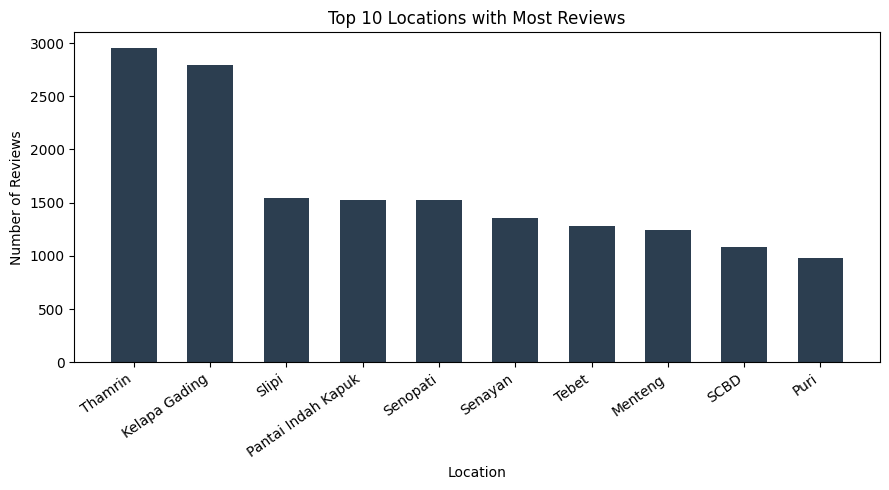

In [29]:
location_count = df['Location'].value_counts()
top_10_location = location_count.head(10)
plt.figure(figsize = (9, 5))
plt.bar(top_10_location.index, top_10_location.values, color='#2C3E50', width=0.6)

plt.xlabel("Location")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Locations with Most Reviews")

plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

data is spreaded across 90 location in jakarta

In [30]:
location_count

Location
Thamrin               2953
Kelapa Gading         2792
Slipi                 1543
Pantai Indah Kapuk    1529
Senopati              1523
                      ... 
Pondok Bambu             6
Jembatan Lima            4
Pasar Rebo               4
Daan Mogot               3
Cililitan                1
Name: count, Length: 90, dtype: int64

Top 10 users with most reviews

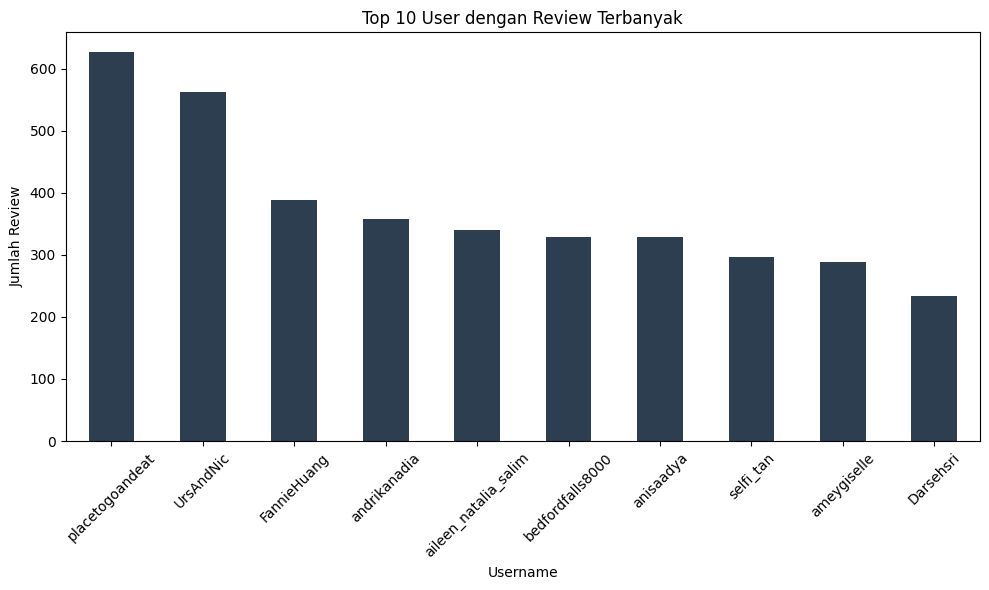

In [31]:
user_review_counts = df['Username'].value_counts()
top_users = user_review_counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_users.plot(kind='bar', color='#2C3E50')
plt.title("Top 10 User dengan Review Terbanyak")
plt.xlabel("Username")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()